# Prediction using Classification Model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder




In [2]:
#Install Shap and Lime for XAI
#!pip install shap lime


In [3]:
import shap
import lime
from lime import lime_tabular  


In [29]:
# Load the dataset
df = pd.read_csv("loan_approval_dataset (1).csv")
df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [24]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [25]:
# Check for missing values
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

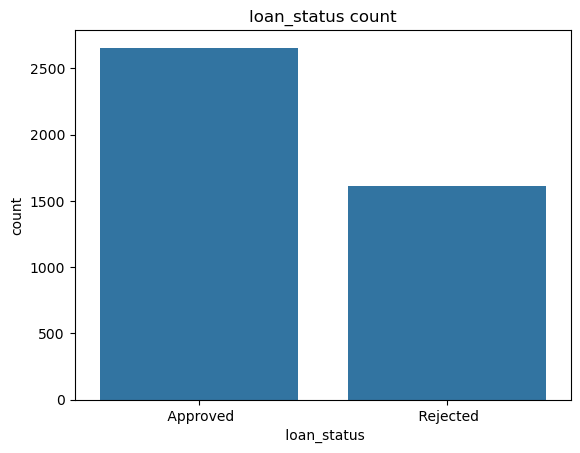

In [33]:
# Plot showing the count of approved or rejected status in the dataset
sns.countplot(data=df, x=" loan_status")
plt.title("loan_status count")
plt.show()


In [35]:
#Check correlation between numerical columns
df.drop([" education"," self_employed"," loan_status"], axis=1).corr()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
loan_id,1.000000,0.005326,0.012592,0.008170,0.009809,0.016323,0.020936,0.018595,-0.000862,0.010765
no_of_dependents,0.005326,1.000000,0.007266,-0.003366,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163
income_annum,0.012592,0.007266,1.000000,0.927470,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093
loan_amount,0.008170,-0.003366,0.927470,1.000000,0.008437,-0.017035,0.594596,0.603188,0.860914,0.788122
loan_term,0.009809,-0.020111,0.011488,0.008437,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177
cibil_score,0.016323,-0.009998,-0.023034,-0.017035,0.007810,1.000000,-0.019947,-0.003769,-0.028618,-0.015478
residential_assets_value,0.020936,0.007376,0.636841,0.594596,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418
commercial_assets_value,0.018595,-0.001531,0.640328,0.603188,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576
luxury_assets_value,-0.000862,0.002817,0.929145,0.860914,0.012490,-0.028618,0.590932,0.591128,1.000000,0.788517
bank_asset_value,0.010765,0.011163,0.851093,0.788122,0.017177,-0.015478,0.527418,0.548576,0.788517,1.000000


In [37]:
#drop columns with high correlation
df = df.drop(['loan_id', ' income_annum', ' bank_asset_value', ' luxury_assets_value'], axis=1)

In [38]:
df.head()

,no_of_dependents,education,self_employed,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,loan_status
0,2,Graduate,No,29900000,12,778,2400000,17600000,Approved
1,0,Not Graduate,Yes,12200000,8,417,2700000,2200000,Rejected
2,3,Graduate,No,29700000,20,506,7100000,4500000,Rejected
3,3,Graduate,No,30700000,8,467,18200000,3300000,Rejected
4,5,Not Graduate,Yes,24200000,20,382,12400000,8200000,Rejected


In [39]:
#Seperate columns into categorical and numerical
categorical_features = [" education", " self_employed"]




In [40]:
#Initialize the encoder to output pandas DataFrames directly
encoder = OneHotEncoder(drop="first", sparse_output=False,dtype=int)
encoder.set_output(transform="pandas")
#Fit and transform the categorical columns
encoded_cats = encoder.fit_transform(df[categorical_features])

#Join the numerical and encoded categorical feature columns
df_numerical = df.drop(columns=categorical_features)
df_e = pd.concat([df_numerical, encoded_cats], axis=1)

# View newly transformed dataset
df_e.head()

,no_of_dependents,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,loan_status,education_ Not Graduate,self_employed_ Yes
0,2,29900000,12,778,2400000,17600000,Approved,0,0
1,0,12200000,8,417,2700000,2200000,Rejected,1,1
2,3,29700000,20,506,7100000,4500000,Rejected,0,0
3,3,30700000,8,467,18200000,3300000,Rejected,0,0
4,5,24200000,20,382,12400000,8200000,Rejected,1,1


In [42]:
#Separate dataset into features (X) and target (y)
X = df_e.drop(" loan_status", axis=1)
y_re = df_e[" loan_status"]


In [43]:
lb = LabelEncoder()
y = lb.fit_transform(y_re)


In [44]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(3415, 8)
(854, 8)


## Randomforestclassifier Model

In [45]:
Model= RandomForestClassifier()



In [46]:
#Run Hyperparameter tuning
param_grid = {
    "n_estimators": [50, 100, 200],       
    "max_depth": [None, 5, 10, 15],       
    "min_samples_split": [2, 5, 10],      
    "criterion": ["gini", "entropy"]      
}

# Setup the Grid Search engine (using 5-Fold Cross-Validation)
grid_search_model = GridSearchCV(estimator=Model, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search_model.fit(X_train, y_train)


best_model = grid_search_model.best_estimator_


In [47]:
# Generate predictions 
MP = best_model.predict(X_test)
MP



array([1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,

In [73]:
#Side by side comparison between loan status from the laon dataset amd Loan status based on model prediction
df2 = pd.DataFrame(MP)
# Sort and display them
df2 = pd.DataFrame({
    'Loan_status': y_test,
    'Model_predict': MP
})

model_importance_df
df2.head(10)

,Loan_status,Model_predict
0,1,1
1,0,0
2,1,1
3,0,0
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,1,1


In [51]:
print(classification_report(y_test, MP))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       536
           1       0.97      0.95      0.96       318

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



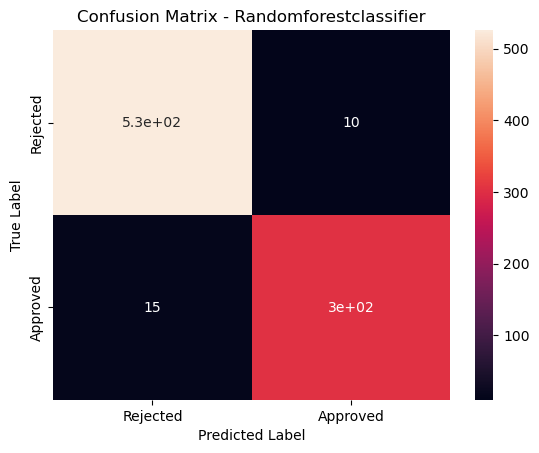

In [98]:
#Confusion Matrix
cm = confusion_matrix(y_test, MP)
sns.heatmap(cm, annot=True, xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
plt.title("Confusion Matrix - Randomforestclassifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [74]:
#Feature Importance of the trained model
importance= best_model.feature_importances_
importance
# Sort and display them
model_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

model_importance_df

,Feature,Importance
3,cibil_score,0.821767
2,loan_term,0.067618
1,loan_amount,0.035597
4,residential_assets_value,0.028325
5,commercial_assets_value,0.028124
0,no_of_dependents,0.011141
7,self_employed_ Yes,0.003888
6,education_ Not Graduate,0.003541


## TreeShap XAI

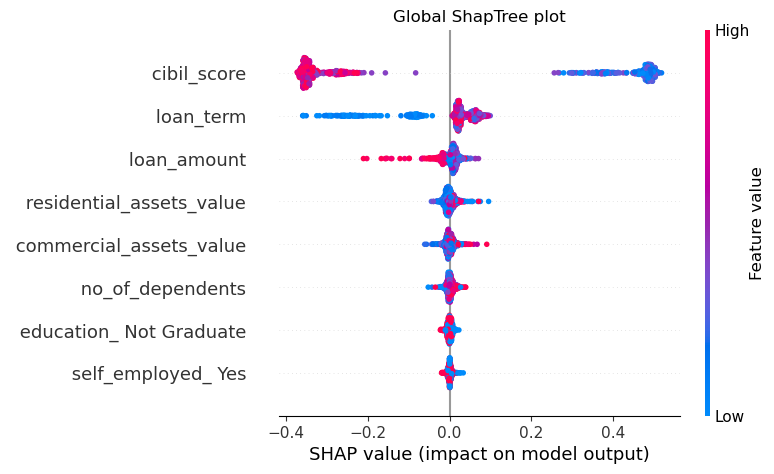

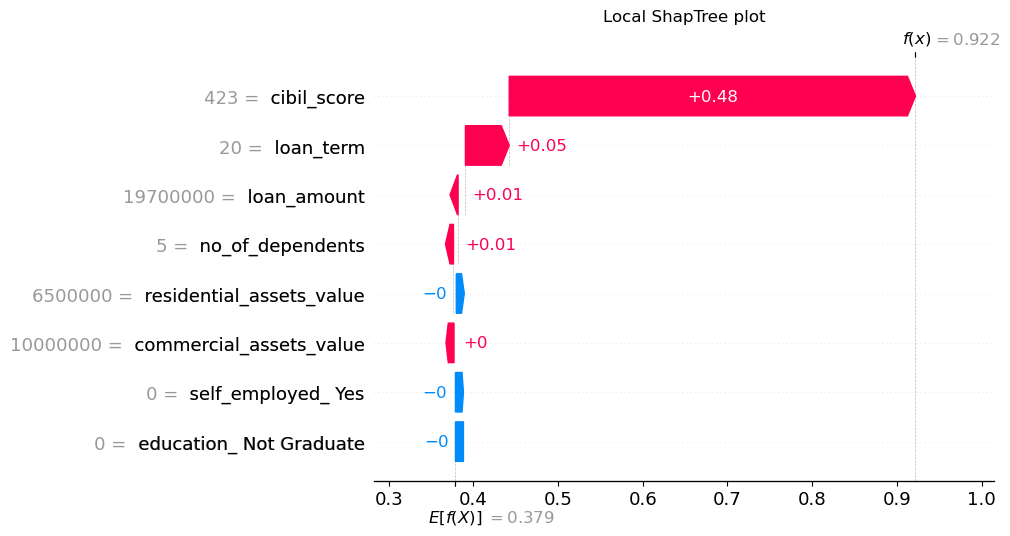

In [93]:
# Run TreeSHAP on trained loan model
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for the test data
shap_values = explainer(X_test)

# Plot the global summary chart of shap values which shows the variable responsible for Model behaviour(Approved/Rejected)
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], X_test,show=False) 
ax.set_title("Global ShapTree plot")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(shap_values[0, :, 1], show=False)
plt.title("Local ShapTree plot")
plt.show()

#### ShapTree for loan model explanation
###### Global ShapTree explanation (Diagram 1)
This plot explains the whole feature in the dataset as a group and not individual

1. cibil_score: The massive cluster of blue dots at the right side indicates a low credit score. This shows that a low credit score heavily pushes the model output to the right, increasing the probability of a Loan Rejection. Also, on the left the pink dots indicates a High Credit score pulling the risk down to zero which increases the probability of a loan acceptance.

2. loan_term: The pink/red dots located to the right side of the graph indicates a Longer loan terms. It means that the longer an applicant takes to pay back a loan, the model views it as a risk, which increases the reason for a rejection and vice versa.

3. loan_amount: The pink/red dots on the left indicates High loan amounts. 

#### Local ShapTree Explanation (Diagram 2)
This plot explains how the model works based on an individual application in the dataset

1. The plot shows exactly how the model walks step-by-step from the base value E[f(x)] = (0.379) to the final prediction f(X) = (0.922).

2. Ccbil_score = 423: This is the massive driving force. Because the applicant's credit score is very low (423), it adds a staggering +0.48 which sends it straight to the rejection probability. This single feature does nearly all the heavy lifting.

3. loan_term = 20: A long 20-year term adds another +0.05 to the risk score, pushing the rejection probability higher.

4. loan_amount = 19700000 and no_of_dependents = 5: These features add to minor risk increments (+1% each).

5. Other Features like residential_assets_value = 6,500,000 and having a graduate education (education_Not Graduate = 0) pull the risk down by fractions of a percent, but it's not enough to counter the bad credit score.


## LIME XAI

In [77]:
#Set up the LIME explainer using your clean, unscaled training data
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=lb.classes_,
    mode="classification"
)

#Explain first applicant in your test set (index 0)
applicant_idx = 0
exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[applicant_idx],
    predict_fn=best_model.predict_proba
)

#Display the Explanation;
from IPython.display import display, HTML
display(HTML(exp.as_html(show_table=True)))


C:\Users\NDIEZE\anaconda3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\NDIEZE\anaconda3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\NDIEZE\anaconda3\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positio

### LIME XAI explained

1. The model evaluated an applicant from our model and found an extreme risk configuration. Only 8% of the ensemble trees voted for "Approved," while 92% voted for "Rejected."

2. The Right Box contains the applicant's raw data profile. This person applied for a loan of 19.7 Million. They have a credit score(cibil_score) of 423. Their loan repayment period (loan_term) is 20 years.

3. The Middle Box shows us how the model evaluated the person. It shows which facts pulled the rope toward "Rejected"(Orange) and which facts pulled toward "Approved"(Blue).
- The Long Orange Bar(cibil_score <= 454.00): Because this person's credit score is 423(which is lower than 454), Team Rejected gets a massive pull. This single reason did 80% of the work to reject the loan.
- The Smaller Orange Bar(loan_term > 16.00): Because their 20-year repayment term is longer than 16 years, it is risky. Team Rejected gets another small pull.
- The Blank/Flat Lines: Features like education or being self-employed didn't pull the rope at all. The model completely ignored them.

4. From the left box(Prediction Probabilities), because there is a 92% chance (0.92), the loan will be Rejected.There is only an 8% chance (0.08) that it will be Approved.

5. The model rejected this specific person with 92% certainty because their credit score is way too low (423) and their payment period is too long (20 years). 